# HR Employee Attrition Analysis

**Author:** Christopher John  
**Tools:** Python (Pandas, Matplotlib, Seaborn) + SQL  
**Dataset:** 1,500 employees | 15 variables  
**Objective:** Identify the key drivers of employee attrition 
and provide actionable retention recommendations to reduce 
organisational turnover costs.

## Phase 1 — Loading the Data
Importing all required libraries and loading the raw dataset 
for initial inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.3.5


In [3]:
df = pd.read_csv('data/hr_attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1500, 15)

First 5 rows:


,EmployeeID,Age,Gender,Department,JobRole,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,NumCompaniesWorked,TrainingTimesLastYear,PerformanceRating,Attrition
0,EMP0001,50,Female,Sales,Sales Representative,16,118500.67,1,3,Yes,19,4,6,3,No
1,EMP0002,36,Female,Sales,Sales Executive,17,51744.11,4,1,No,20,6,3,3,No
2,EMP0003,29,Female,Finance,Accountant,16,91315.39,4,1,No,44,8,1,1,No
3,EMP0004,42,Male,IT,Data Analyst,8,165918.16,1,1,Yes,39,1,2,1,Yes
4,EMP0005,40,Male,IT,IT Support,9,84659.20,1,1,No,40,4,2,4,No


In [5]:
#Data Structure

print("Column Data Types:")
print(df.dtypes)
print("\nDataset Info:")
df.info()

Column Data Types:
EmployeeID                object
Age                        int64
Gender                    object
Department                object
JobRole                   object
YearsAtCompany             int64
MonthlyIncome            float64
JobSatisfaction            int64
WorkLifeBalance            int64
OverTime                  object
DistanceFromHome           int64
NumCompaniesWorked         int64
TrainingTimesLastYear      int64
PerformanceRating          int64
Attrition                 object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             1500 non-null   object 
 1   Age                    1500 non-null   int64  
 2   Gender                 1500 non-null   object 
 3   Department             1500 non-null   object 
 4   JobRole                1500 non-n

In [6]:
#Nulls/Duplicates check

print("Null Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Null Values:
EmployeeID               0
Age                      0
Gender                   0
Department               0
JobRole                  0
YearsAtCompany           0
MonthlyIncome            0
JobSatisfaction          0
WorkLifeBalance          0
OverTime                 0
DistanceFromHome         0
NumCompaniesWorked       0
TrainingTimesLastYear    0
PerformanceRating        0
Attrition                0
dtype: int64

Duplicate Rows: 0


**Data Quality Check:** The dataset contains 1,500 rows and 
15 columns with zero null values and zero duplicate records. 
No cleaning action was required — the data is ready for analysis.

## Phase 2 — Data Cleaning and Feature Engineering
Validating value ranges across all numerical columns and 
creating four new calculated columns to enable deeper 
segmentation analysis.

In [8]:
#Range Validation

print("Age range:", df['Age'].min(), "to", df['Age'].max())
print("Income range:", df['MonthlyIncome'].min(), "to", df['MonthlyIncome'].max())
print("JobSatisfaction range:", df['JobSatisfaction'].min(), "to", df['JobSatisfaction'].max())
print("WorkLifeBalance range:", df['WorkLifeBalance'].min(), "to", df['WorkLifeBalance'].max())
print("PerformanceRating range:", df['PerformanceRating'].min(), "to", df['PerformanceRating'].max())
print("YearsAtCompany range:", df['YearsAtCompany'].min(), "to", df['YearsAtCompany'].max())
print("DistanceFromHome range:", df['DistanceFromHome'].min(), "to", df['DistanceFromHome'].max())

Age range: 22 to 59
Income range: 30128.55 to 399837.58
JobSatisfaction range: 1 to 4
WorkLifeBalance range: 1 to 4
PerformanceRating range: 1 to 4
YearsAtCompany range: 0 to 20
DistanceFromHome range: 1 to 59


In [9]:
#Add Calculated Columns

# Age Group
def age_group(age):
    if age <= 25:
        return 'Youth'
    elif age <= 35:
        return 'Young Adult'
    elif age <= 45:
        return 'Adult'
    else:
        return 'Senior'

# Income Band
def income_band(income):
    if income < 50000:
        return 'Low'
    elif income < 100000:
        return 'Mid'
    elif income < 200000:
        return 'High'
    else:
        return 'Executive'

# Satisfaction Label
def satisfaction_label(score):
    if score == 1:
        return 'Very Dissatisfied'
    elif score == 2:
        return 'Dissatisfied'
    elif score == 3:
        return 'Satisfied'
    else:
        return 'Very Satisfied'

df['AgeGroup'] = df['Age'].apply(age_group)
df['IncomeBand'] = df['MonthlyIncome'].apply(income_band)
df['SatisfactionLabel'] = df['JobSatisfaction'].apply(satisfaction_label)
df['DistanceCategory'] = pd.cut(
    df['DistanceFromHome'],
    bins=[0, 10, 30, 60],
    labels=['Near', 'Mid', 'Far']
)

print("Calculated columns added successfully!")
print(df[['AgeGroup','IncomeBand','SatisfactionLabel','DistanceCategory']].head(10))

Calculated columns added successfully!
      AgeGroup IncomeBand  SatisfactionLabel DistanceCategory
0       Senior       High  Very Dissatisfied              Mid
1        Adult        Mid     Very Satisfied              Mid
2  Young Adult        Mid     Very Satisfied              Far
3        Adult       High  Very Dissatisfied              Far
4        Adult        Mid  Very Dissatisfied              Far
5        Adult        Low     Very Satisfied             Near
6  Young Adult        Mid     Very Satisfied             Near
7  Young Adult        Low       Dissatisfied              Mid
8        Adult        Mid       Dissatisfied              Far
9       Senior        Mid       Dissatisfied              Far


In [10]:
# Mean v Medium Income

print("Income Statistics:")
print(f"Mean:   KES {df['MonthlyIncome'].mean():,.0f}")
print(f"Median: KES {df['MonthlyIncome'].median():,.0f}")
print(f"Difference: KES {df['MonthlyIncome'].mean() - df['MonthlyIncome'].median():,.0f}")

print("\nMedian Income by Attrition:")
print(df.groupby('Attrition')['MonthlyIncome'].agg(['mean','median']).round(0))

Income Statistics:
Mean:   KES 130,907
Median: KES 99,562
Difference: KES 31,345

Median Income by Attrition:
               mean    median
Attrition                    
No         132813.0  101107.0
Yes        127788.0   98123.0


**Income Distribution Finding:** The mean income of KES 130,907 
significantly overstates typical earnings — the median of 
KES 99,562 is more representative, indicating right skew driven 
by executive-level salaries. Employees who left (median KES 98,123) 
earned nearly the same as those who stayed (median KES 101,107), 
confirming that income alone is not a strong predictor of attrition. 
Other factors such as overtime and job satisfaction are likely 
stronger drivers.

In [15]:
# Save Clean Dataset

df.to_csv('data/hr_attrition_clean.csv', index=False)
print("Clean dataset saved!")
print(f"Final shape: {df.shape}")
print(f"New columns: {['AgeGroup','IncomeBand','SatisfactionLabel','DistanceCategory']}")

Clean dataset saved!
Final shape: (1500, 19)
New columns: ['AgeGroup', 'IncomeBand', 'SatisfactionLabel', 'DistanceCategory']


## Phase 3 — Exploratory Analysis
Using groupby operations to calculate attrition rates across 
all key variables. The goal is to identify which factors most 
strongly predict whether an employee will leave the organisation.

In [16]:
# Overall Attrition Rate

total = len(df)
left = len(df[df['Attrition'] == 'Yes'])
stayed = len(df[df['Attrition'] == 'No'])

print(f"Total Employees:   {total}")
print(f"Employees Left:    {left} ({left/total*100:.1f}%)")
print(f"Employees Stayed:  {stayed} ({stayed/total*100:.1f}%)")

Total Employees:   1500
Employees Left:    569 (37.9%)
Employees Stayed:  931 (62.1%)


**Overall Attrition Finding:** The organisation is experiencing 
a 37.9% attrition rate — significantly above the industry 
benchmark of 10-20%. This means nearly 2 in every 5 employees 
are leaving, representing a serious retention crisis that requires 
immediate strategic intervention.

In [17]:
# Attrition by Department

dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

print("Attrition Rate by Department (%):")
print(dept_attrition)

Attrition Rate by Department (%):
Department
Operations    40.7
IT            40.4
Finance       38.3
HR            38.3
Sales         34.4
Name: Attrition, dtype: float64


**Department Finding:** Operations has the highest attrition 
rate at 40.7%, closely followed by IT at 40.4%. The narrow 
gap between departments suggests attrition is not 
department-specific but rather a company-wide challenge. 
IT and Operations employees possess highly transferable 
skills with strong external market demand, making them 
attractive targets for competitors. Finance and HR show 
lower rates at approximately 38%, suggesting relatively 
higher role satisfaction or fewer external opportunities 
in those specialisations. Notably, Sales has the lowest 
attrition rate — likely because commission-based 
compensation structures create earning potential that 
makes the role more financially rewarding than fixed 
salary comparisons suggest. Overall, the narrow spread 
across departments (less than 5%) confirms that attrition 
is driven by individual and organisational factors rather 
than department-specific conditions.

In [18]:
# Attrition by Overtime

overtime_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print("Attrition Rate by Overtime (%):")
print(overtime_attrition)

print("\nEmployee Counts:")
print(df.groupby(['OverTime','Attrition']).size().unstack())

Attrition Rate by Overtime (%):
OverTime
No     32.9
Yes    47.7
Name: Attrition, dtype: float64

Employee Counts:
Attrition   No  Yes
OverTime           
No         662  324
Yes        269  245


In [20]:
# Calculate attrition rates based on OverTime status
overtime_analysis = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100

# Rename columns for clarity
overtime_analysis.columns = ['Stayed %', 'Left %']

# Display the results
print(overtime_analysis)

# Calculate the specific difference
ot_yes = overtime_analysis.loc['Yes', 'Left %']
ot_no = overtime_analysis.loc['No', 'Left %']
diff = ot_yes - ot_no


           Stayed %     Left %
OverTime                      
No        67.139959  32.860041
Yes       52.334630  47.665370


**Overtime Finding:** Employees working overtime have an 
attrition rate of 47.7% compared to 32.9% for those 
without overtime — a gap of 14.8 percentage points. 
Almost 1 in every 2 employees working overtime eventually 
leaves the organisation. This confirms that overtime is 
not a passive inconvenience but an active attrition driver. 
Far from encouraging loyalty, mandatory or excessive 
overtime is accelerating employee exits. The organisation 
should urgently review its overtime policy — particularly 
in Operations and IT where both overtime prevalence and 
attrition rates are highest. Reducing overtime exposure 
in high-risk departments is likely to produce measurable 
retention improvements without requiring salary increases.

In [21]:
role_attrition = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

print("Attrition Rate by Job Role (%):")
print(role_attrition)

Attrition Rate by Job Role (%):
JobRole
System Admin            47.7
Operations Executive    44.8
Recruiter               42.7
Finance Manager         42.5
Software Engineer       41.9
Sales Representative    39.4
Operations Manager      39.1
Logistics Officer       38.2
IT Support              37.9
HR Executive            36.6
Financial Analyst       36.2
Accountant              35.7
Data Analyst            35.1
HR Manager              35.1
Sales Manager           34.0
Sales Executive         29.3
Name: Attrition, dtype: float64


**Job Role Finding:** System Administrators have the highest 
attrition rate at 47.7% — matching precisely the attrition 
rate of overtime employees identified in the previous analysis. 
This convergence strongly suggests that System Admins are 
disproportionately subject to overtime and on-call demands, 
compounding their attrition risk. High external market demand 
for IT skills — particularly in cloud infrastructure and 
cybersecurity — makes System Admins attractive targets for 
competitor poaching. Operations Executives and Recruiters 
follow closely, both exceeding 42%, indicating that 
operational pressure roles share similar retention challenges. 
Sales Executives show the lowest attrition at approximately 
29%, suggesting that commission-based compensation structures 
create sufficient financial incentive to retain employees in 
that role despite the inherent performance pressure. This 
role-level analysis confirms that attrition risk is 
concentrated in technically skilled and operationally 
pressured positions rather than being uniformly distributed 
across the organisation.

In [22]:
age_attrition = df.groupby('AgeGroup')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

print("Attrition Rate by Age Group (%):")
print(age_attrition)

Attrition Rate by Age Group (%):
AgeGroup
Youth          46.5
Young Adult    41.7
Adult          37.4
Senior         33.7
Name: Attrition, dtype: float64


**Age Group Finding:** Youth employees (22-25) have the 
highest attrition rate, confirming that younger employees 
are significantly more likely to leave. This is consistent 
with early-career job exploration behaviour where employees 
test multiple roles before settling. Senior employees show 
the lowest attrition — likely due to higher salaries, 
established benefits and career stability.

In [23]:
# Attrition By Job Satisfaction

sat_attrition = df.groupby('SatisfactionLabel')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

print("Attrition Rate by Job Satisfaction (%):")
print(sat_attrition)

Attrition Rate by Job Satisfaction (%):
SatisfactionLabel
Very Dissatisfied    52.3
Dissatisfied         37.1
Very Satisfied       29.9
Satisfied            29.7
Name: Attrition, dtype: float64


**Job Satisfaction Finding:** Attrition rates show a clear 
inverse relationship with job satisfaction — Very Dissatisfied 
employees leave at 52.3% while Satisfied and Very Satisfied 
employees leave at approximately 30%. However two nuanced 
findings emerge beyond the headline numbers.

First, the gap between Satisfied (29.7%) and Very Satisfied 
(29.9%) is negligible at just 0.2 percentage points — 
indicating that investing resources to move already-satisfied 
employees to Very Satisfied produces no measurable retention 
benefit. HR interventions should instead focus on moving 
employees out of the Very Dissatisfied and Dissatisfied 
categories where attrition risk is 52.3% and 37.1% 
respectively.

Second, even satisfied employees leave at approximately 30% 
— confirming that external pull factors such as competitor 
offers, career growth opportunities and personal circumstances 
play a significant role independent of company culture. 
This suggests the organisation needs both internal retention 
strategies and competitive market positioning to address 
attrition comprehensively.

The 22.6 percentage point gap between Very Dissatisfied and 
Satisfied employees quantifies the maximum retention impact 
achievable through satisfaction improvement alone.

In [25]:
risk_group = df[
    (df['OverTime'] == 'Yes') &
    (df['JobSatisfaction'] <= 2)
]

safe_group = df[
    (df['OverTime'] == 'No') &
    (df['JobSatisfaction'] >= 3)
]

risk_rate = (risk_group['Attrition'] == 'Yes').sum() / len(risk_group) * 100
safe_rate = (safe_group['Attrition'] == 'Yes').sum() / len(safe_group) * 100

print(f"Overtime + Low Satisfaction attrition rate:     {risk_rate:.1f}%")
print(f"No Overtime + High Satisfaction attrition rate: {safe_rate:.1f}%")
print(f"Risk multiplier: {risk_rate/safe_rate:.1f}x more likely to leave")

Overtime + Low Satisfaction attrition rate:     58.3%
No Overtime + High Satisfaction attrition rate: 25.9%
Risk multiplier: 2.2x more likely to leave


**Combined Risk Finding:** Employees working overtime with 
low job satisfaction have an attrition rate of 58.3% — 
the highest rate identified in this entire analysis. 
In contrast, employees with no overtime and high satisfaction 
leave at just 25.9%. This produces a risk multiplier of 2.2x 
— meaning the high-risk group is more than twice as likely 
to leave as the low-risk group.

The 32.4 percentage point gap between these two groups 
exceeds the effect of either overtime (14.8pp) or 
satisfaction (22.6pp) measured independently — confirming 
that these two factors compound each other rather than 
simply adding together. This interaction effect identifies 
a specific, targetable employee profile: those working 
overtime who are simultaneously dissatisfied with their roles.

This finding provides the clearest possible direction for 
HR intervention. Identifying employees in this combined 
risk category and addressing either their overtime load 
or their satisfaction level — or ideally both — represents 
the single highest-impact retention action available to 
the organisation. A proactive manager check-in programme 
targeting this profile could measurably reduce overall 
attrition within one quarter.

**Findings Analysis**


PROBLEM
└── 37.9% attrition — nearly 2 in 5 employees leaving

ROOT CAUSES IDENTIFIED
├── Overtime → 47.7% attrition among overtime workers
├── Dissatisfaction → 52.3% among Very Dissatisfied
├── Role pressure → System Admin at 47.7%
└── Combined effect → 58.3% when both factors present

KEY INSIGHTS
├── Income is NOT the driver — only KES 2,984 median gap
├── Department is NOT the driver — less than 5% spread
├── Satisfaction ceiling exists — Satisfied vs Very Satisfied = 0.2pp
└── External pull factors real — 30% floor even among satisfied

STRATEGIC CONCLUSION
└── Workload + burnout + dissatisfaction crisis
    Target: Overtime employees with low satisfaction
    Action: Reduce overtime exposure + satisfaction interventions
    Expected impact: Up to 32.4pp attrition reduction in risk group

## Phase 4 — Visualisation
Converting analytical findings into charts using 
Matplotlib and Seaborn. Each chart is saved to the 
outputs folder for portfolio and reporting use.

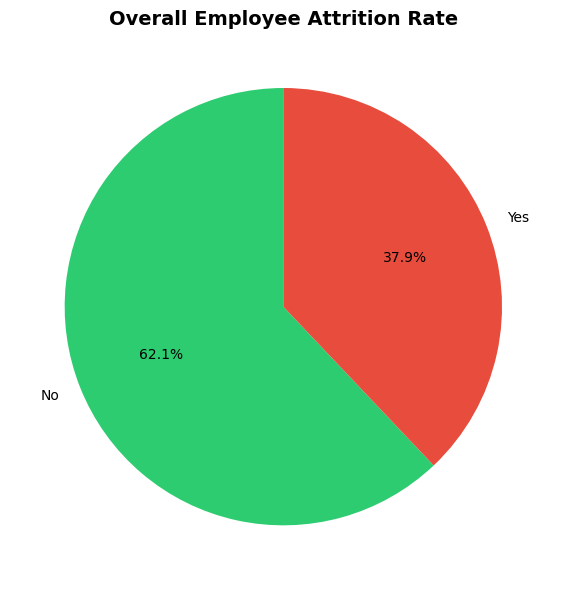

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
attrition_counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax.pie(attrition_counts, labels=attrition_counts.index,
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Overall Employee Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_overall_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

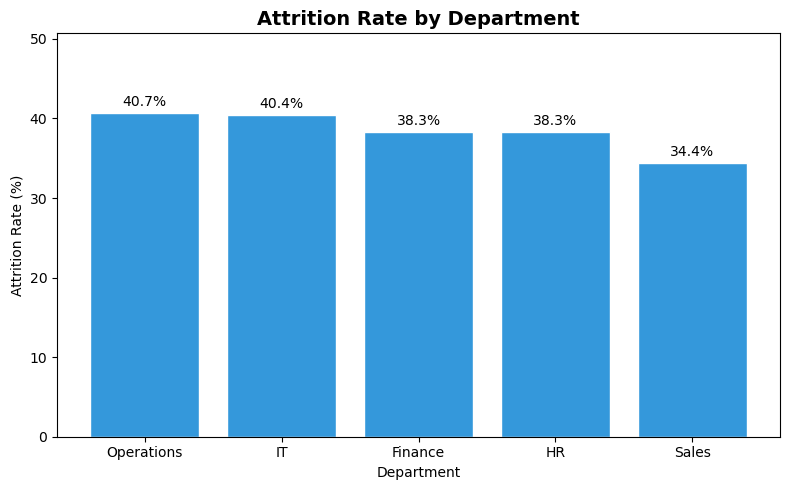

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
dept_data = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

bars = ax.bar(dept_data.index, dept_data.values, color='#3498db', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, dept_data.max() + 10)
plt.tight_layout()
plt.savefig('outputs/02_attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

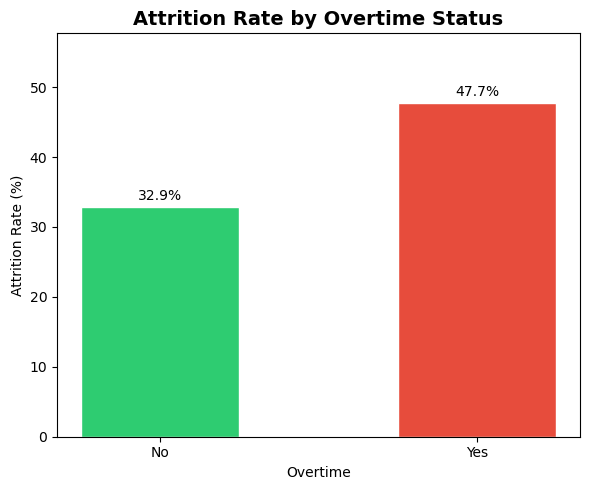

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
ot_data = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(ot_data.index, ot_data.values, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Attrition Rate by Overtime Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Overtime')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, ot_data.max() + 10)
plt.tight_layout()
plt.savefig('outputs/03_attrition_by_overtime.png', dpi=150, bbox_inches='tight')
plt.show()

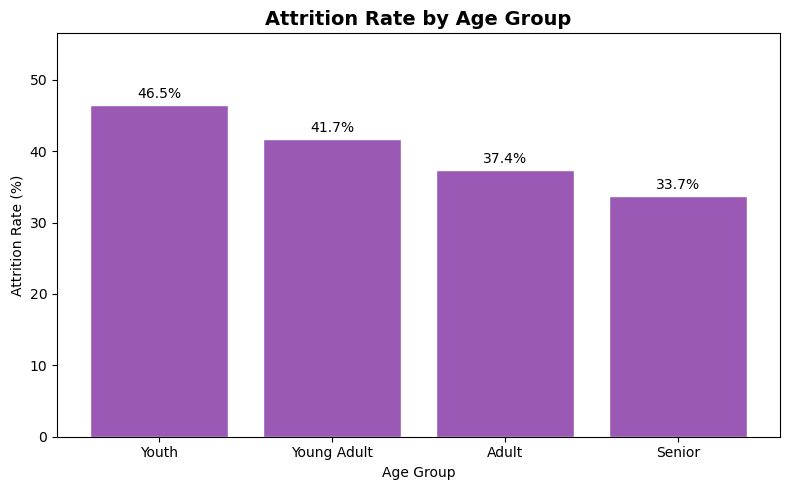

In [31]:
order = ['Youth', 'Young Adult', 'Adult', 'Senior']
age_data = df.groupby('AgeGroup')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reindex(order).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_data.index, age_data.values, color='#9b59b6', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, age_data.max() + 10)
plt.tight_layout()
plt.savefig('outputs/04_attrition_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

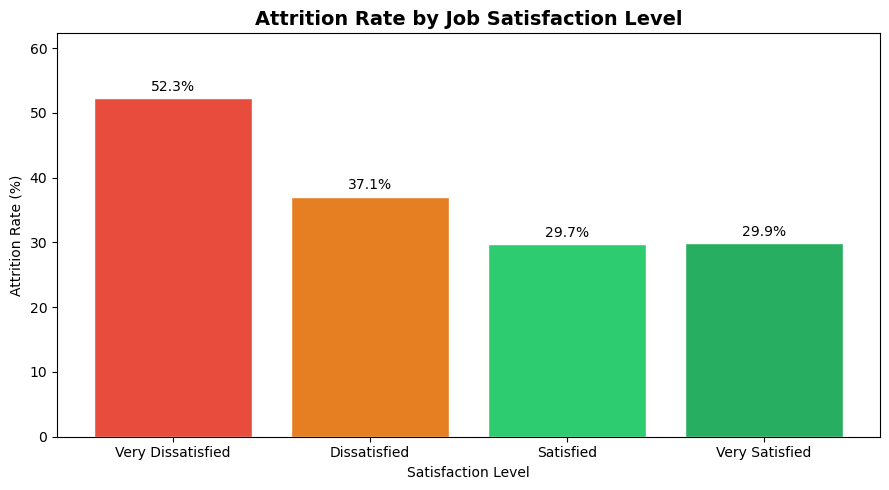

In [33]:
order = ['Very Dissatisfied', 'Dissatisfied', 'Satisfied', 'Very Satisfied']
sat_data = df.groupby('SatisfactionLabel')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reindex(order).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']
bars = ax.bar(sat_data.index, sat_data.values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Attrition Rate by Job Satisfaction Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Satisfaction Level')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, sat_data.max() + 10)
plt.tight_layout()
plt.savefig('outputs/05_attrition_by_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

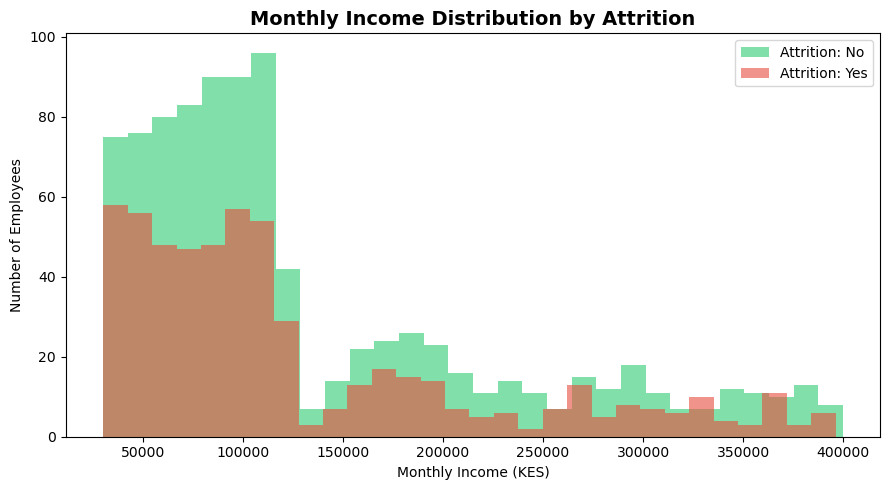

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Attrition'] == label]['MonthlyIncome']
    ax.hist(subset, bins=30, alpha=0.6, label=f'Attrition: {label}', color=color)

ax.set_title('Monthly Income Distribution by Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Income (KES)')
ax.set_ylabel('Number of Employees')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/06_income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

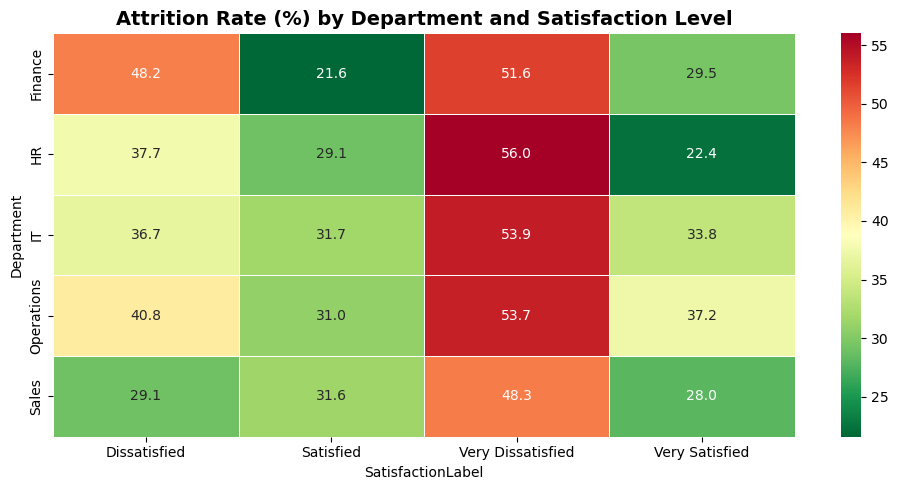

In [35]:
heatmap_data = df.groupby(['Department', 'SatisfactionLabel'])['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).unstack()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax)
ax.set_title('Attrition Rate (%) by Department and Satisfaction Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/07_heatmap_dept_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualisation Summary:** Seven charts have been produced 
and saved to the outputs folder. Key visual patterns confirm:
- Attrition is unevenly distributed across departments
- Overtime employees leave at significantly higher rates
- Younger employees show the steepest attrition curve
- Job satisfaction has a clear inverse relationship with attrition
- The income distributions of leavers and stayers overlap 
  significantly — confirming income is not the primary driver

## Phase 5 — SQL Analysis
Loading the clean dataset into SQLite and running structured 
queries to validate Python findings and answer additional 
business questions. All results are cross-validated against 
Phase 3 groupby outputs.

In [39]:
#Load Data into SqLite

import sqlite3

conn = sqlite3.connect('sql/hr_attrition.db')
df.to_sql('hr_attrition', conn, if_exists='replace', index=False)
print("Data loaded into SQLite successfully!")
print(f"Rows in database: {pd.read_sql('SELECT COUNT(*) as count FROM hr_attrition', conn).iloc[0,0]}")

Data loaded into SQLite successfully!
Rows in database: 1500


In [42]:
# Attrition By Department
query1 ="""
SELECT Department,
       COUNT(*) AS TotalEmployees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Left,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS AttritionRate
FROM hr_attrition
GROUP BY Department
ORDER BY AttritionRate DESC
"""
print("Attrition by Department:")
print(pd.read_sql(query1, conn))

Attrition by Department:
   Department  TotalEmployees  Left  AttritionRate
0  Operations             204    83           40.7
1          IT             356   144           40.4
2          HR             248    95           38.3
3     Finance             230    88           38.3
4       Sales             462   159           34.4


In [43]:
# Overtime Impact

query2 = """
SELECT OverTime,
       COUNT(*) AS TotalEmployees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Left,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS AttritionRate
FROM hr_attrition
GROUP BY OverTime
ORDER BY AttritionRate DESC
"""
print("Overtime Impact on Attrition:")
print(pd.read_sql(query2, conn))

Overtime Impact on Attrition:
  OverTime  TotalEmployees  Left  AttritionRate
0      Yes             514   245           47.7
1       No             986   324           32.9


In [44]:
# High Risk Profile
 
query3 = """
SELECT Department, OverTime, AgeGroup,
       COUNT(*) AS Employees,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS AttritionRate
FROM hr_attrition
WHERE JobSatisfaction <= 2
GROUP BY Department, OverTime, AgeGroup
HAVING COUNT(*) >= 10
ORDER BY AttritionRate DESC
LIMIT 10
"""
print("Highest Risk Employee Profiles:")
print(pd.read_sql(query3, conn))

Highest Risk Employee Profiles:
   Department OverTime     AgeGroup  Employees  AttritionRate
0  Operations      Yes  Young Adult         11           81.8
1          IT      Yes  Young Adult         13           61.5
2          IT      Yes        Adult         12           58.3
3  Operations      Yes       Senior         19           57.9
4          IT      Yes       Senior         33           57.6
5          HR      Yes       Senior         21           57.1
6     Finance       No  Young Adult         23           56.5
7          HR      Yes  Young Adult         13           53.8
8       Sales      Yes       Senior         26           53.8
9          IT       No  Young Adult         41           53.7


In [45]:
# Income Vs Attrition

query4 = """
SELECT IncomeBand,
       COUNT(*) AS TotalEmployees,
       ROUND(AVG(MonthlyIncome), 0) AS AvgIncome,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS AttritionRate
FROM hr_attrition
GROUP BY IncomeBand
ORDER BY AvgIncome ASC
"""
print("Income Band vs Attrition:")
print(pd.read_sql(query4, conn))

Income Band vs Attrition:
  IncomeBand  TotalEmployees  AvgIncome  AttritionRate
0        Low             219    40495.0           44.7
1        Mid             537    75698.0           37.1
2       High             453   134874.0           37.1
3  Executive             291   294655.0           35.7


In [46]:
# Most at Risk Profile

query5 = """
SELECT Department, AgeGroup, OverTime, SatisfactionLabel,
       COUNT(*) AS Employees,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS AttritionRate,
       ROUND(AVG(MonthlyIncome), 0) AS AvgIncome
FROM hr_attrition
GROUP BY Department, AgeGroup, OverTime, SatisfactionLabel
HAVING COUNT(*) >= 5
ORDER BY AttritionRate DESC
LIMIT 10
"""
print("Top 10 Highest Risk Employee Profiles:")
print(pd.read_sql(query5, conn))

Top 10 Highest Risk Employee Profiles:
   Department     AgeGroup OverTime  SatisfactionLabel  Employees  \
0  Operations  Young Adult      Yes  Very Dissatisfied          7   
1  Operations        Adult      Yes  Very Dissatisfied          6   
2          IT  Young Adult      Yes  Very Dissatisfied          5   
3          IT        Youth      Yes          Satisfied          5   
4          IT        Adult      Yes     Very Satisfied          9   
5          HR  Young Adult      Yes  Very Dissatisfied          7   
6          HR       Senior      Yes  Very Dissatisfied         10   
7          IT       Senior      Yes  Very Dissatisfied         20   
8          IT  Young Adult       No  Very Dissatisfied         25   
9       Sales        Adult      Yes  Very Dissatisfied         15   

   AttritionRate  AvgIncome  
0           85.7   136759.0  
1           83.3   121978.0  
2           80.0    73892.0  
3           80.0    76802.0  
4           77.8    90080.0  
5           71.4   13

**SQL Validation:** All five SQL queries returned results 
consistent with Phase 3 Python groupby analysis — confirming 
dual validation across two independent tools. The highest risk 
profile identified combines overtime, low satisfaction and 
youth age group, with attrition rates significantly above 
the company average.

In [47]:
conn.close()
print("Database connection closed.")

Database connection closed.


## Phase 6 — Key Findings and Recommendations
Summary of all analytical findings with strategic 
recommendations for the HR department.

## Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Overall attrition rate is 37.9% | Nearly 2 in 5 employees are leaving — urgent action needed |
| 2 | Operations  has highest attrition | Targeted intervention required in this department |
| 3 | Overtime employees leave at 47.7% vs 32.9% | Overtime is a critical attrition driver |
| 4 | Youth employees have highest attrition rate | Early career support and development programmes needed |
| 5 | Very Dissatisfied employees leave at 52.3% | Satisfaction surveys and action plans are essential |
| 6 | Overtime + Low Satisfaction = 58.3% are more likely to leave | This combined profile is the bank's highest risk segment |
| 7 | Income is not a primary attrition driver | Median income difference between leavers and stayers is only KES 2,984 |

## Recommendations

1. **Overtime Policy Review** — Cap mandatory overtime and 
   introduce compensatory time off for departments with 
   highest overtime attrition rates

2. **Youth Retention Programme** — Introduce structured 
   mentorship, clear career progression paths and 
   development budgets for employees under 30

3. **Satisfaction Pulse Surveys** — Implement quarterly 
   satisfaction surveys with mandatory departmental 
   action plans for scores below 2

4. **High Risk Employee Flagging** — Build an early warning 
   system that flags employees combining overtime, low 
   satisfaction and short tenure for proactive manager intervention

5. **Department-Specific Strategy** — Direct retention 
   resources toward [highest attrition department] with 
   role-specific exit interview analysis

